In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Specify base directory where all files are stored
basedir = '/mnt/disks/scratch/p16_data/p16_locus_figure_data'
# All data is available in gs://gtex-calico-p16/locus_figure/
# Almost all files are read directly from this bucket; the only file that must
# be available locally in basedir is:
# gs://gtex-calico-p16/locus_figure/gencode.v26.GRCh38.annotation.p16_locus.gtf

In [3]:
import pandas as pd
import numpy as np
import re
import copy
import glob
import os
import pyBigWig
import scipy.signal
import scipy.ndimage as ndimage
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'Helvetica', 'svg.fonttype':'none', 'pdf.fonttype':42})
import seaborn as sns

import qtl.annotation
import qtl.plot
import qtl.gtex
import qtl.genotype as gt
colors_df = qtl.gtex.get_colors_df()

matplotlib.rcParams['figure.dpi'] = 72
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

#### Specify locus

In [4]:
# !grep "ENSG00000147889\|ENSG00000240498\|ENSG00000147883\|ENSG00000099810" /resources/gencode.v39.GRCh38.annotation.gtf \
#     > /mnt/disks/scratch/p16_data/p16_locus_figure_data/gencode.v39.GRCh38.annotation.p16_locus.gtf
# !gsutil cp /mnt/disks/scratch/p16_data/p16_locus_figure_data/gencode.v39.GRCh38.annotation.p16_locus.gtf \
#     gs://gtex-calico-p16/locus_figure/
annot = qtl.annotation.Annotation(f"{basedir}/gencode.v39.GRCh38.annotation.p16_locus.gtf")

Genes parsed: 4


In [5]:
# select specific isoforms for visualization
p16_gene = copy.deepcopy(annot.get_gene('CDKN2A'))
p16_gene.transcripts = [t for t in p16_gene.transcripts if t.id.startswith('ENST00000304494')]
p16_gene.start_pos = p16_gene.transcripts[0].start_pos
p16_gene.end_pos = p16_gene.transcripts[0].end_pos
p16_gene.name = 'p16'

p14_gene = copy.deepcopy(annot.get_gene('CDKN2A'))
p14_gene.transcripts = [t for t in p14_gene.transcripts if t.id.startswith('ENST00000579755')]
p14_gene.start_pos = p14_gene.transcripts[0].start_pos
p14_gene.end_pos = p14_gene.transcripts[0].end_pos
p14_gene.name = 'p14'

p15_gene = copy.deepcopy(annot.get_gene('CDKN2B'))
p15_gene.transcripts = [t for t in p15_gene.transcripts if t.id.startswith('ENST00000276925')]
p15_gene.start_pos = p15_gene.transcripts[0].start_pos
p15_gene.end_pos = p15_gene.transcripts[0].end_pos
p15_gene.name = 'p15'

# ANRIL_short_gene = copy.deepcopy(annot.get_gene('CDKN2B-AS1'))
# ANRIL_short_gene.transcripts = [t for t in ANRIL_short_gene.transcripts if t.id.startswith('ENST00000584351')]
# ANRIL_short_gene.start_pos = ANRIL_short_gene.transcripts[0].start_pos
# ANRIL_short_gene.end_pos = ANRIL_short_gene.transcripts[0].end_pos
# ANRIL_short_gene.name = 'ANRIL short'

ANRIL_long_gene = copy.deepcopy(annot.get_gene('CDKN2B-AS1'))
ANRIL_long_gene.transcripts = [t for t in ANRIL_long_gene.transcripts if t.id.startswith('ENST00000428597')]
ANRIL_long_gene.start_pos = ANRIL_long_gene.transcripts[0].start_pos
ANRIL_long_gene.end_pos = ANRIL_long_gene.transcripts[0].end_pos
ANRIL_long_gene.name = 'ANRIL'

mtap_gene = copy.deepcopy(annot.get_gene('MTAP'))
mtap_gene.set_transcripts([mtap_gene.get_mane_transcript()])

p16_locus_genes = [mtap_gene, p16_gene, p14_gene, p15_gene, ANRIL_long_gene]

In [6]:
# locus coordinates
region_str = 'chr9:21750000-22500000'  # expanded region
chrom, pos = region_str.split(':')
start_pos, end_pos = map(int, pos.split('-'))
pos_vec = [f"{chrom}:{i}" for i in range(start_pos, end_pos+1)]

### Preprocessing

#### UKB LD data

In [7]:
import qtl.liftover
import qtl.ukb
import importlib

os.environ["CHAIN_FILE"] = qtl.liftover.download_chain_file()
importlib.reload(qtl.liftover)

<module 'qtl.liftover' from '/mnt/disks/resources/github/pyqtl/qtl/liftover.py'>

In [18]:
# UKB LD data from s3://broad-alkesgroup-ukbb-ld/UKBB_LD
ld_dir = Path.cwd().joinpath("ukb_ld")
ld_dir.mkdir(exist_ok=True)
ld_region = qtl.ukb.download_ld(region_str, ld_dir)
qtl.ukb.liftover_ld(os.path.join(ld_dir, f"{ld_region}.gz"))
ukbb_ld_df = qtl.ukb.load_ld(os.path.join(ld_dir, f"{ld_region}.npz"))
ukbb_ld_df = ukbb_ld_df ** 2
pos = np.array([int(i.split('_')[1]) for i in ukbb_ld_df.columns])
m = (pos >= start_pos) & (pos <= end_pos)
ukbb_ld_df = ukbb_ld_df.loc[m, ukbb_ld_df.columns[m]]
# ukbb_ld_df.to_parquet('gs://gtex-calico-p16/locus_figure/UKBB_LD.p16_expanded_locus.parquet')

download: s3://broad-alkesgroup-ukbb-ld/UKBB_LD/chr9_21000001_24000001.npz to ukb_ld/chr9_21000001_24000001.npz
download: s3://broad-alkesgroup-ukbb-ld/UKBB_LD/chr9_21000001_24000001.gz to ukb_ld/chr9_21000001_24000001.gz


Reading liftover chains
Mapping coordinates


#### UKB fine-mapping data

In [20]:
# data from https://www.finucanelab.org/data
# https://www.dropbox.com/s/cdsdgwxkxkcq8cn/UKBB_94traits_release1.1.tar.gz

col_s = pd.read_csv('/mnt/disks/scratch/ukb/release1.1/UKBB_94traits_release1.cols',
                    sep='\t', header=None, index_col=0).squeeze('columns')
ukb_df = pd.read_csv('/mnt/disks/scratch/ukb/release1.1/UKBB_94traits_release1.GRCh38_liftover.bed.gz',
                     sep='\t', header=None, names=col_s.index)

ukb_df = ukb_df[ukb_df['chromosome'] == chrom].copy()
ukb_df = ukb_df[ukb_df['cs_id'] != -1]  # drop rows without CS

ukb_df.insert(1, 'position', ukb_df['start']+1)
ukb_df = ukb_df.sort_values(['position'])
ukb_df['variant'] = 'chr' + ukb_df['variant']

ukb_df = ukb_df[(ukb_df['position'] >= start_pos) & (ukb_df['position'] <= end_pos)]

ukb_df.insert(2, 'variant_id', (ukb_df['chromosome'] + '_' + (ukb_df['start']+1).astype(str) + '_'
                                + ukb_df['allele1'] + '_' + ukb_df['allele2'] + '_b38'))

ukb_df.drop(['start', 'end', 'variant', 'allele1', 'allele2', 'minorallele', 'cohort', 'LD_HWE', 'LD_SV',
                   'beta_marginal', 'se_marginal', 'chisq_marginal', 'beta_posterior', 'sd_posterior'], axis=1, inplace=True)
ukb_df.rename(columns={'chromosome': 'chr'}, inplace=True)
ukb_df.reset_index(drop=True, inplace=True)

ukb_df.rename(columns={'trait':'trait_id'}, inplace=True)
# ukb_df.to_csv("gs://gtex-calico-p16/locus_figure/UKBB_94traits_release1.p16_expanded_locus.txt", sep='\t', index=False)

#### GTEx V10 eQTLs

In [21]:
fm_df = []
for f in sorted(glob.glob("/mnt/disks/scratch/V10_release/GTEx_Analysis_v10_eQTL/*.v10.eQTLs.SuSiE_summary.parquet")):
    tissue_id = os.path.basename(f).split('.')[0]
    df = pd.read_parquet(f)
    df = df[df['gene_name'].isin(['MTAP', 'CDKN2A', 'CDKN2B', 'CDKN2B-AS1'])].copy()
    if len(df) > 0:
        df['tissue_id'] = tissue_id
        fm_df.append(df)
fm_df = pd.concat(fm_df).reset_index(drop=True)
fm_df['chr'] = fm_df['variant_id'].apply(lambda x: x.split('_')[0])
fm_df['position'] = fm_df['variant_id'].apply(lambda x: int(x.split('_')[1]))
# fm_df.to_parquet('gs://gtex-calico-p16/locus_figure/GTEx_v10.SuSiE_finemapping.parquet')

### Load preprocessed inputs

In [22]:
ukb_df = pd.read_csv("gs://gtex-calico-p16/locus_figure/UKBB_94traits_release1.p16_expanded_locus.txt", sep='\t')
# select traits
ukb_df = ukb_df[~ukb_df['trait_id'].isin(
    ['TC', 'WBC', 'DBP', 'T2D_BMI', 'Glucose', 'TP', 'Height', 'Plt', 'Mono', 'MCV', 'Eosino']
)]
# rename traits
ukb_df['trait_id'] = ukb_df['trait_id'].str.replace('_Combined', '')
d = {
    'HbA1c': 'Hemoglobin A1c',
    'T2D': 'Type II diabetes',
    'ApoB': 'Apolipoprotein B',
    'CAD': 'Coronary artery disease',
    'PP': 'Pulse pressure',
    'Lym': 'Lymphocyte count',
    'AG': 'Albumin/globulin ratio',
    'Glaucoma': 'Glaucoma',
    'IGF1': 'IGF1', #'Insulin-like growth factor 1',
}
ukb_df['trait_id'] = ukb_df['trait_id'].map(d)
ukb_df['trait_id'] = pd.Categorical(ukb_df['trait_id'], categories=d.values(), ordered=True)
ukb_df = ukb_df.sort_values(['trait_id', 'position'])
ukb_df = ukb_df[ukb_df['method'] == 'SUSIE'].copy()
ukb_df['trait_category'] = 'UKB GWAS'

gtex_pip_df = pd.read_parquet('gs://gtex-calico-p16/locus_figure/GTEx_v10.SuSiE_finemapping.parquet')
gtex_pip_df['trait_category'] = colors_df.loc[gtex_pip_df['tissue_id'], 'tissue_abbrv'].values
gtex_pip_df['trait_id'] = gtex_pip_df['tissue_id'].map(colors_df['tissue_title']) + ' - ' + gtex_pip_df['gene_name']

In [23]:
drop_tissues = [
    'Adipose_Subcutaneous',
    'Adipose_Visceral_Omentum',
    'Adrenal_Gland',
    'Artery_Coronary',
    'Brain_Anterior_cingulate_cortex_BA24',
    'Brain_Caudate_basal_ganglia',
    'Brain_Cortex',
    'Brain_Frontal_Cortex_BA9',
    'Brain_Nucleus_accumbens_basal_ganglia',
    'Cells_Cultured_fibroblasts',
    'Colon_Sigmoid',
    'Colon_Transverse',
    'Esophagus_Gastroesophageal_Junction',
    'Esophagus_Mucosa',
    'Esophagus_Muscularis',
    'Heart_Atrial_Appendage',
    'Lung',
    'Muscle_Skeletal',
    'Ovary',
    'Pancreas',
    'Skin_Sun_Exposed_Lower_leg',
    'Spleen',
    'Stomach',
    'Testis',
    'Vagina',
]

In [24]:
# collapse eQTLs
def collapse_cs(df):
    return df.loc[df.groupby('variant_id')['pip'].idxmax()].copy()

collapsed_pip_df = []
for gene_name in ['CDKN2A', 'CDKN2B', 'CDKN2B-AS1', 'MTAP']:
    if gene_name == 'MTAP':
        df = collapse_cs(gtex_pip_df[(gtex_pip_df['gene_name'] == gene_name) & ~gtex_pip_df['tissue_id'].isin(drop_tissues)])
    else:
        df = collapse_cs(gtex_pip_df[gtex_pip_df['gene_name'] == gene_name])
    if gene_name == 'CDKN2B-AS1':
        gene_name = 'ANRIL'
    df['trait_id'] = gene_name
    df['trait_category'] = 'eQTL'
    collapsed_pip_df.append(df)
collapsed_pip_df = pd.concat(collapsed_pip_df).reset_index(drop=True)
collapsed_pip_df = collapsed_pip_df[(collapsed_pip_df['position'] >= start_pos) & (collapsed_pip_df['position'] <= end_pos - 5e4)]

In [25]:
# lead variants from GWAS catalog
locus_gwas_pip_df = pd.read_csv('gs://gtex-calico-p16/locus_figure/GWAS_Catalog_variants_111124.txt', sep='\t')
# drop selected traits
locus_gwas_pip_df = locus_gwas_pip_df[~locus_gwas_pip_df['trait_id'].isin(
    ['Endometrial Cancer', 'Keratinocyte Carcinoma', 'Myeloma', 'Prostate Cancer', 'Non-Melanoma Skin Cancer', 'Pan-cancer']
)]

# collapse by trait and position, select smallest p-value
locus_gwas_pip_df = locus_gwas_pip_df.groupby(['trait_id', 'position'], as_index=False, sort=False).apply(
    lambda x: x.loc[x['pval'].idxmin()], include_groups=False)

# sort order
order = ['Breast Cancer', 'Colorectal Cancer', 'Glioma', 'Leukemia', 'Lung Cancer', 'Melanoma']
locus_gwas_pip_df['trait_id'] = pd.Categorical(locus_gwas_pip_df['trait_id'], categories=order, ordered=True)
locus_gwas_pip_df = locus_gwas_pip_df.sort_values(['trait_id', 'position'])
locus_gwas_pip_df['trait_id'] = locus_gwas_pip_df['trait_id'].str.replace(' Cancer', '')
locus_gwas_pip_df['trait_category'] = locus_gwas_pip_df['trait_category'].str.replace(' Cancer', '')

# group
s = ['Breast', 'Colorectal', 'Glioma', 'Leukemia']
locus_gwas_pip_df.loc[locus_gwas_pip_df['trait_id'].isin(s), 'trait_id'] = ', '.join(s).capitalize()
s = ['Lung', 'Melanoma']
locus_gwas_pip_df.loc[locus_gwas_pip_df['trait_id'].isin(s), 'trait_id'] = ', '.join(s).capitalize()
locus_gwas_pip_df['trait_category'] = 'Cancer GWAS'

In [26]:
ukbb_ld_df = pd.read_parquet('gs://gtex-calico-p16/locus_figure/UKBB_LD.p16_expanded_locus.parquet')
ld_bounds = qtl.ukb.get_ld_blocks(ukbb_ld_df)

#### Plot

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


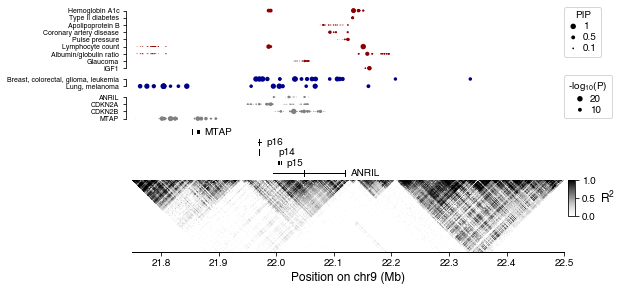

In [27]:
pip_colors = {
    'UKB GWAS': 'darkred',
    'eQTL': 'gray',
    'Cancer GWAS': 'darkblue',
}

ax = qtl.plot.plot_locus_summary(region_str,
                                 ld_df=ukbb_ld_df, #ld_bounds=ld_bounds,
                                 pip_df=[ukb_df, locus_gwas_pip_df, collapsed_pip_df], 
                                 pip_colors=pip_colors, pip_legend=False,
                                 gene=p16_locus_genes, ld_marker_size=0.1, dl=2.25)
# add legends
for x in [1, 0.5, 0.1]:
    ax[0].scatter(np.nan, np.nan, s=30*x, fc='k', ec='none', label=x)
ax[0].legend(loc='upper left', bbox_to_anchor=(1,1), borderaxespad=0,
             title='PIP', labelspacing=0.2, handlelength=1, handletextpad=0.5)
for x in [20, 10]:
    ax[1].scatter(np.nan, np.nan, s=30*x/20, fc='k', ec='none', label=x)
ax[1].legend(loc='upper left', bbox_to_anchor=(1,1), borderaxespad=0,
             title="-log$\mathregular{_{10}}$(P)",
             labelspacing=0.2, handlelength=1, handletextpad=0.5)
plt.savefig('GWAS_catalog_cancer_locus_PIPs.condensed.pdf', dpi=300)